DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:

df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    int64  
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Embarked     891 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 69.7 KB


(891, 10)

In [4]:
df.head(10)

,Unnamed: 0,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,1,0,3,0,22,1,0,7.2500,0
1,1,2,1,1,1,38,1,0,71.2833,1
2,2,3,1,3,1,26,0,0,7.9250,0
3,3,4,1,1,1,35,1,0,53.1000,0
4,4,5,0,3,0,35,0,0,8.0500,0
5,5,6,0,3,0,29,0,0,8.4583,2
6,6,7,0,1,0,54,0,0,51.8625,0
7,7,8,0,3,0,2,3,1,21.0750,0
8,8,9,1,3,1,27,0,2,11.1333,0
9,9,10,1,2,1,14,1,0,30.0708,1


In [ ]:
df[df["Fare"] == 0]

,Unnamed: 0,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
179,179,180,0,3,0,36,0,0,0.0,0
263,263,264,0,1,0,40,0,0,0.0,0
271,271,272,1,3,0,25,0,0,0.0,0
277,277,278,0,2,0,29,0,0,0.0,0
302,302,303,0,3,0,19,0,0,0.0,0
413,413,414,0,2,0,29,0,0,0.0,0
466,466,467,0,2,0,29,0,0,0.0,0
481,481,482,0,2,0,29,0,0,0.0,0
597,597,598,0,3,0,49,0,0,0.0,0
633,633,634,0,1,0,29,0,0,0.0,0


: 

In [5]:
df.isnull().sum()

Unnamed: 0     0
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [6]:
df.describe()

,Unnamed: 0,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,445.000000,446.000000,0.383838,2.308642,0.352413,29.544332,0.523008,0.381594,32.204208,0.361392
std,257.353842,257.353842,0.486592,0.836071,0.477990,13.013778,1.102743,0.806057,49.693429,0.635673
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,222.500000,223.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,445.000000,446.000000,0.000000,3.000000,0.000000,29.000000,0.000000,0.000000,14.454200,0.000000
75%,667.500000,668.500000,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,890.000000,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000



Output Insights

38% of passengers survived (mean of Survived = 0.38)

Age ranges from 0.42 to 80 years

Fare ranges from 0 to 512 — very skewed

Most passengers were in Pclass 3 (median = 3)

In [7]:
# 1. Dropping useless columns
df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# 2. Fill missing Age with median
imputer = KNNImputer(n_neighbors=5)
df[['Age']] = imputer.fit_transform(df[['Age']]).astype(int)

# 3. Fill missing Embarked with mode
df['Embarked']= df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 4. Convert Sex to binary
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 5. Convert Embarked to numbers
df['Embarked'] = df['Embarked'].replace({'S': 0, 'C': 1, 'Q': 2})

KeyError: "['Name', 'Ticket', 'Cabin'] not found in axis"

In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22,1,0,7.2500,0
1,2,1,1,1,38,1,0,71.2833,1
2,3,1,3,1,26,0,0,7.9250,0
3,4,1,1,1,35,1,0,53.1000,0
4,5,0,3,0,35,0,0,8.0500,0
5,6,0,3,0,29,0,0,8.4583,2
6,7,0,1,0,54,0,0,51.8625,0
7,8,0,3,0,2,3,1,21.0750,0
8,9,1,3,1,27,0,2,11.1333,0
9,10,1,2,1,14,1,0,30.0708,1


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    int64  
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    object 
dtypes: float64(1), int64(7), object(1)
memory usage: 62.8+ KB


In [ ]:
df[['Age']] = imputer.fit_transform(df[['Age']]).astype(int)

In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22,1,0,7.2500,0
1,2,1,1,1,38,1,0,71.2833,1
2,3,1,3,1,26,0,0,7.9250,0
3,4,1,1,1,35,1,0,53.1000,0
4,5,0,3,0,35,0,0,8.0500,0
5,6,0,3,0,29,0,0,8.4583,2
6,7,0,1,0,54,0,0,51.8625,0
7,8,0,3,0,2,3,1,21.0750,0
8,9,1,3,1,27,0,2,11.1333,0
9,10,1,2,1,14,1,0,30.0708,1


In [ ]:
df["Embarked"]

0      0
1      1
2      0
3      0
4      0
      ..
886    0
887    0
888    0
889    1
890    2
Name: Embarked, Length: 891, dtype: object

In [ ]:
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age              int64
SibSp            int64
Parch            int64
Fare           float64
Embarked       float64
dtype: object


CHECKING FOR OUTLIERS

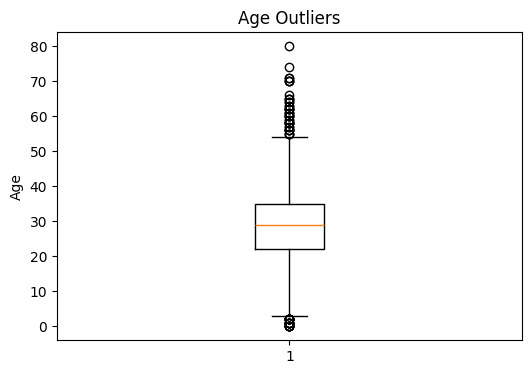

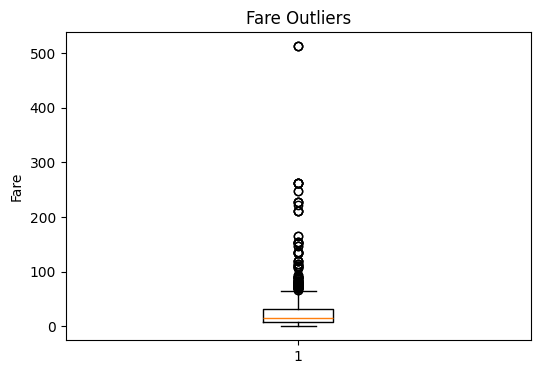

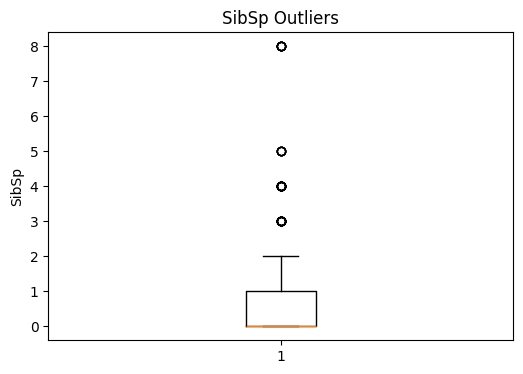

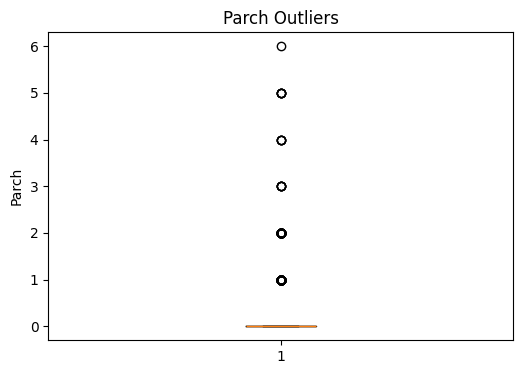

In [ ]:
# Age
plt.figure(figsize=(6, 4))
plt.boxplot(df['Age'])
plt.title('Age Outliers')
plt.ylabel('Age')
plt.show();

# Fare
plt.figure(figsize=(6, 4))
plt.boxplot(df['Fare'])
plt.title('Fare Outliers')
plt.ylabel('Fare')
plt.show();

# SibSp
plt.figure(figsize=(6, 4))
plt.boxplot(df['SibSp'])
plt.title('SibSp Outliers')
plt.ylabel('SibSp')
plt.show();

# Parch
plt.figure(figsize=(6, 4))
plt.boxplot(df['Parch'])
plt.title('Parch Outliers')
plt.ylabel('Parch')
plt.show();

Age

Several outliers above 60 years — passengers aged 65-80
Main bulk of passengers between 18-40 years
Outliers are realistic — elderly passengers genuinely existed


Fare

Most extreme outliers of all columns
One passenger paid nearly 512 — extremely high luxury ticket
Several others paid 200-300
Majority paid between 0-50
Highly right skewed — consider log transformation before modelling


SibSp (Siblings/Spouses aboard)

Most passengers had 0-1 siblings/spouses
Outliers show passengers with 3, 4, 5, 8 — large families
The passenger with 8 siblings is unusual but real


Parch (Parents/Children aboard)

Most passengers had 0 parents/children
Outliers show values up to 6 — large families travelling together


In summary, All these values are real so i will keep them to make my model meaningful.

In [ ]:
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

Age: 66 outliers
Fare: 116 outliers
SibSp: 46 outliers
Parch: 213 outliers


In [ ]:
# 1. Missing values
print("Missing Values:")
print(df.isnull().sum())

# 2. Duplicates
print("\nDuplicates:", df.duplicated().sum())

# 3. Data types
print("\nData Types:")
print(df.dtypes)

# 4. Shape
print("\nShape:", df.shape)

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

Duplicates: 0

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age              int64
SibSp            int64
Parch            int64
Fare           float64
Embarked        object
dtype: object

Shape: (891, 9)


In [ ]:
df['Embarked'] = df['Embarked'].astype(int)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    int64  
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    int64  
dtypes: float64(1), int64(8)
memory usage: 62.8 KB


In [ ]:
df.to_csv("Titanic-Dataset.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22,1,0,7.2500,0
1,2,1,1,1,38,1,0,71.2833,1
2,3,1,3,1,26,0,0,7.9250,0
3,4,1,1,1,35,1,0,53.1000,0
4,5,0,3,0,35,0,0,8.0500,0


EDA

Univariate analysis

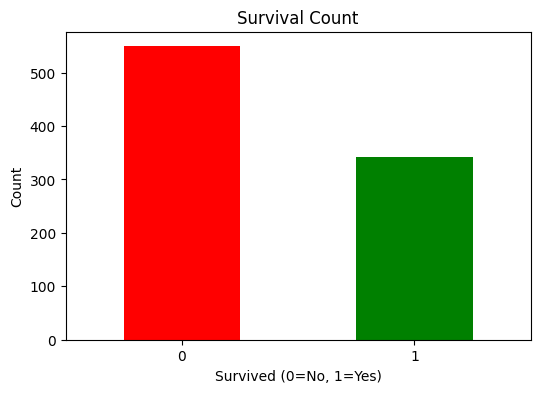

In [ ]:
# ploting a class balance for the survivers
plt.figure(figsize=(6, 4))
df['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Survival Count')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

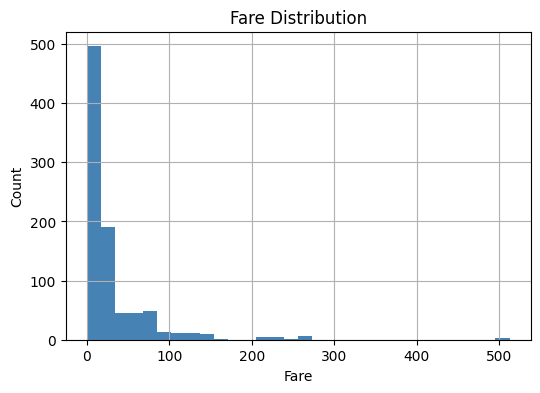

In [ ]:
# Ploting for the fare
plt.figure(figsize=(6, 4))
df['Fare'].hist(bins=30, color='steelblue')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

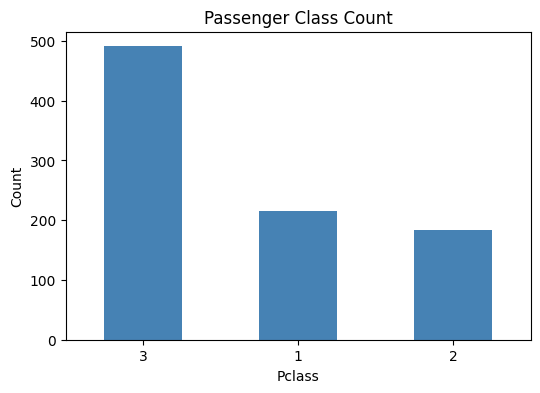

In [ ]:
plt.figure(figsize=(6, 4))
df['Pclass'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Passenger Class Count')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

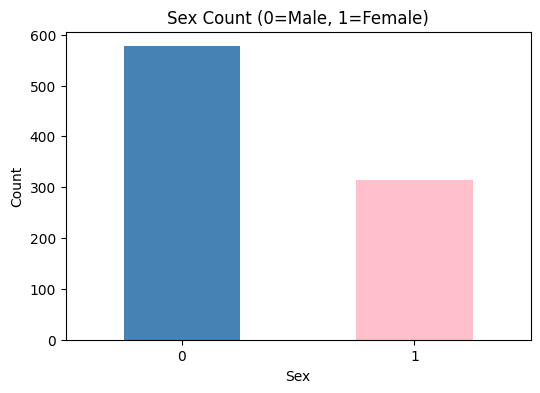

In [ ]:
plt.figure(figsize=(6, 4))
df['Sex'].value_counts().plot(kind='bar', color=['steelblue', 'pink'])
plt.title('Sex Count (0=Male, 1=Female)')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

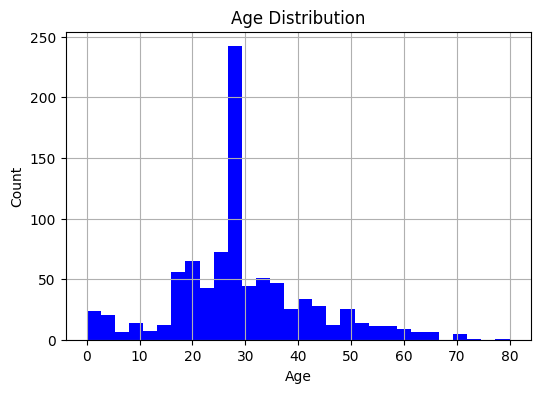

In [ ]:
plt.figure(figsize=(6, 4))
df['Age'].hist(bins=30, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Key Insights 

finding    And   Implication

62% died            Imbalanced dataset — watch model bias

55% were 3rd class  Lower class = lower survival chance

Fare heavily skewed Log transform before modelling

Age spike at 28     This is because of the method used in filling the age

2x more males       Males likely had much lower survival rate

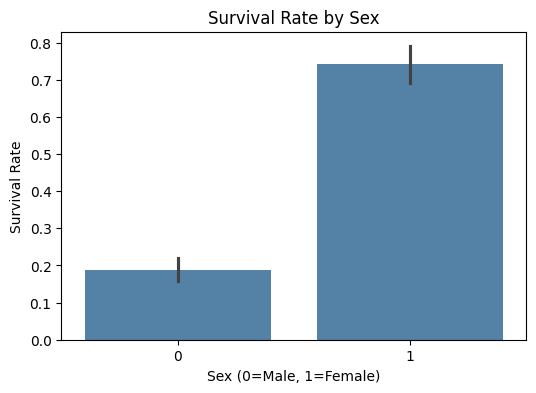

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df, color='steelblue')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex (0=Male, 1=Female)')
plt.ylabel('Survival Rate')
plt.show()

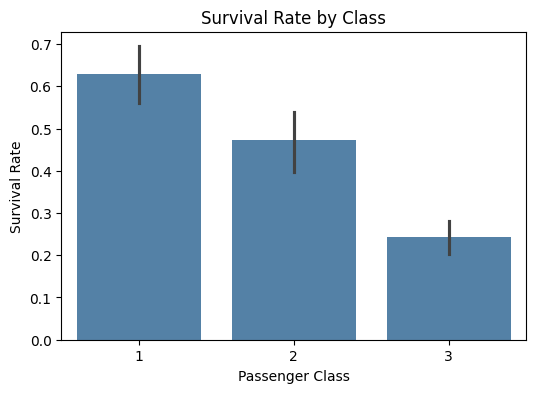

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df, color='steelblue')
plt.title('Survival Rate by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

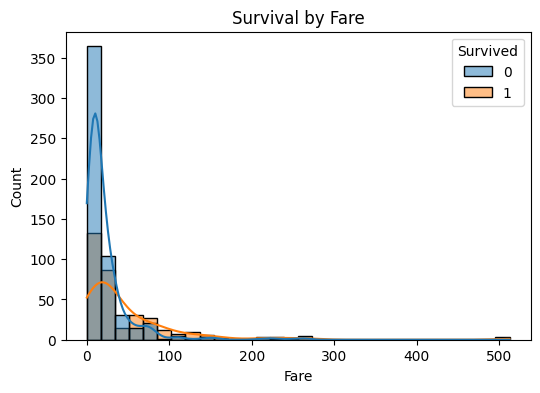

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Fare', hue='Survived', bins=30, kde=True)
plt.title('Survival by Fare')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

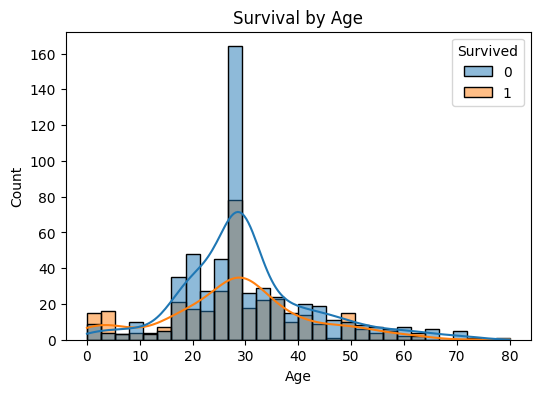

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Survival by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

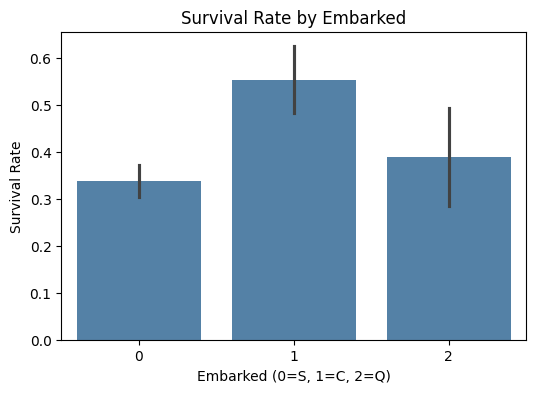

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Embarked', y='Survived', data=df, color='steelblue')
plt.title('Survival Rate by Embarked')
plt.xlabel('Embarked (0=S, 1=C, 2=Q)')
plt.ylabel('Survival Rate')
plt.show();